In [ ]:
#Importing library
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
import numpy as np

np.random.seed(1000)

In [ ]:
#Instantiation
AlexNet = Sequential()

In [ ]:
#1st Convolutional Layer
AlexNet.add(Conv2D(filters=96, input_shape=(256,256,3), kernel_size=(11,11), strides=(4,4), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#2nd Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#3rd Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#4th Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#5th Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

In [ ]:
#Passing it to a Fully Connected layer
AlexNet.add(Flatten())

# 1st Fully Connected Layer
AlexNet.add(Dense(4096, input_shape=(32,32,3,)))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

# Add Dropout to prevent overfitting
AlexNet.add(Dropout(0.4))

#2nd Fully Connected Layer
AlexNet.add(Dense(4096))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#3rd Fully Connected Layer
AlexNet.add(Dense(1000))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#Output Layer
AlexNet.add(Dense(10))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('softmax'))

#Model Summary
AlexNet.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 8, 8, 96)          34944     
                                                                 
 batch_normalization_9 (Batc  (None, 8, 8, 96)         384       
 hNormalization)                                                 
                                                                 
 activation_9 (Activation)   (None, 8, 8, 96)          0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 4, 4, 96)         0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 4, 4, 256)         614656    
                                                                 
 batch_normalization_10 (Bat  (None, 4, 4, 256)       

In [ ]:
# Compiling the model
AlexNet.compile(loss = keras.losses.categorical_crossentropy, optimizer= 'Nadam', metrics=['accuracy'])

In [ ]:
#Openai install, imports, utilities
!pip install openai

import os
import openai
import urllib.request

# openai.api_key = os.getenv("KEY")

prompts = ["an airplane", "car", "real bird", "cat", "a deer", "a dog", "frogs", "horses", "ships", "trucks"]
myPath = "/content/pictures"
os.makedir(myPath)

In [ ]:
# Generating images with openai and save them
for p in prompts:
  response = openai.Image.create(
      prompt= p,
      n=1,
      response_format='url',
      size="256x256"
      )
  if "data" in response:
    for key, obj in enumerate(response["data"]):
      filename ='my_image_'+str(key)+".jpg"
      fullfilename = os.path.join(myPath, filename)
      urllib.request.urlretrieve(obj['url'], fullfilename)
    print('Images have been downloaded and saved locally')
  else:
    print("Failed to generate image")


In [ ]:
#Use saved images as dataset


In [ ]:
#Keras library for CIFAR dataset
from keras.datasets import cifar10
(x_train, y_train),(x_test, y_test)=cifar10.load_data()

#Train-validation-test split
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=.3)

#Dimension of the CIFAR10 dataset
print((x_train.shape,y_train.shape))
print((x_val.shape,y_val.shape))
print((x_test.shape,y_test.shape))

170498071/170498071 [==============================] - 6s 0us/step
((35000, 32, 32, 3), (35000, 1))
((15000, 32, 32, 3), (15000, 1))
((10000, 32, 32, 3), (10000, 1))


In [ ]:
#Onehot Encoding the labels.
from sklearn.utils.multiclass import unique_labels
from keras.utils import to_categorical

#Since we have 10 classes we should expect the shape[1] of y_train,y_val and y_test to change from 1 to 10
y_train=to_categorical(y_train)
y_val=to_categorical(y_val)
y_test=to_categorical(y_test)

#Verifying the dimension after one hot encoding
print((x_train.shape,y_train.shape))
print((x_val.shape,y_val.shape))
print((x_test.shape,y_test.shape))

((35000, 32, 32, 3), (35000, 10))
((15000, 32, 32, 3), (15000, 10))
((10000, 32, 32, 3), (10000, 10))


In [ ]:
#Image Data Augmentation
from keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(rotation_range=2, horizontal_flip=True,zoom_range=.1 )

val_generator = ImageDataGenerator(rotation_range=2, horizontal_flip=True,zoom_range=.1)

test_generator = ImageDataGenerator(rotation_range=2, horizontal_flip= True,zoom_range=.1)

#Fitting the augmentation defined above to the data
train_generator.fit(x_train)
val_generator.fit(x_val)
test_generator.fit(x_test)

#Learning Rate Annealer
from keras.callbacks import ReduceLROnPlateau
lrr= ReduceLROnPlateau(   monitor='val_accuracy',   factor=.01,   patience=3,  min_lr=1e-5)

#Defining the parameters
batch_size= 32
epochs=50
learn_rate=.001

training= train_generator.flow(x_train, y_train, batch_size=batch_size)
vald = val_generator.flow(x_val, y_val, batch_size=batch_size)

In [ ]:
#Training the model
AlexNet.fit(training,
            epochs = epochs,
            steps_per_epoch = x_train.shape[0]//batch_size,
            validation_data = vald,
            validation_steps = 250,
            callbacks = [lrr],
            verbose=1)

Epoch 1/50
1093/1093 [==============================] - 30s 26ms/step - loss: 1.7341 - accuracy: 0.3765 - val_loss: 1.5816 - val_accuracy: 0.4374 - lr: 0.0100
Epoch 2/50
1093/1093 [==============================] - 28s 25ms/step - loss: 1.4601 - accuracy: 0.4816 - val_loss: 1.8076 - val_accuracy: 0.3774 - lr: 0.0100
Epoch 3/50
1093/1093 [==============================] - 29s 26ms/step - loss: 1.3559 - accuracy: 0.5240 - val_loss: 1.3210 - val_accuracy: 0.5324 - lr: 0.0100
Epoch 4/50
1093/1093 [==============================] - 28s 26ms/step - loss: 1.2642 - accuracy: 0.5579 - val_loss: 1.3454 - val_accuracy: 0.5194 - lr: 0.0100
Epoch 5/50
1093/1093 [==============================] - 28s 26ms/step - loss: 1.2054 - accuracy: 0.5799 - val_loss: 1.2765 - val_accuracy: 0.5512 - lr: 0.0100
Epoch 6/50
1093/1093 [==============================] - 28s 26ms/step - loss: 1.1442 - accuracy: 0.6042 - val_loss: 1.2147 - val_accuracy: 0.5691 - lr: 0.0100
Epoch 7/50
1093/1093 [========================

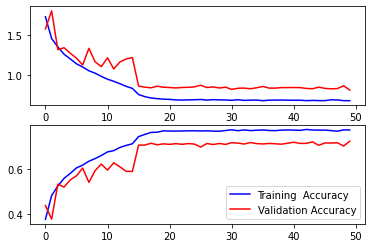

In [ ]:
#After successful training, we will visualize its performance.

import matplotlib.pyplot as plt
#Plotting the training and validation loss

f,ax=plt.subplots(2,1) #Creates 2 subplots under 1 column

#Assigning the first subplot to graph training loss and validation loss
ax[0].plot(AlexNet.history.history['loss'],color='b',label='Training Loss')
ax[0].plot(AlexNet.history.history['val_loss'],color='r',label='Validation Loss')

#Plotting the training accuracy and validation accuracy
ax[1].plot(AlexNet.history.history['accuracy'],color='b',label='Training  Accuracy')
ax[1].plot(AlexNet.history.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()


In [ ]:
#Defining function for confusion matrix plot
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

#Print Confusion matrix
    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

np.set_printoptions(precision=2)

313/313 [==============================] - 1s 4ms/step
[3 1 8 ... 5 4 7]
[3 8 8 ... 5 1 7]
Confusion matrix, without normalization
Normalized confusion matrix


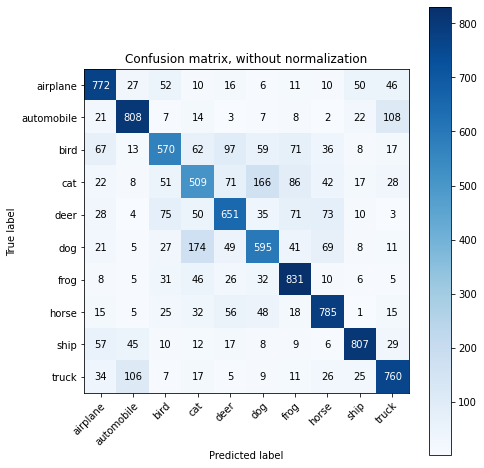

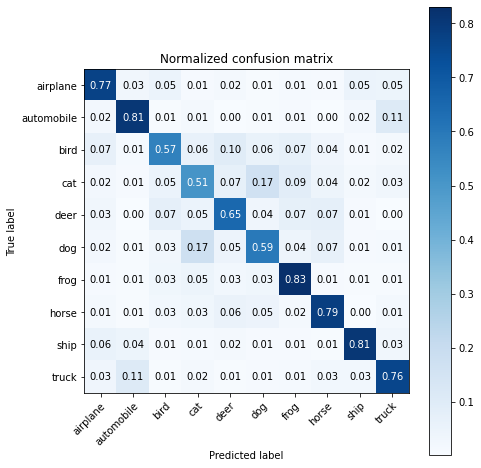

In [ ]:
#Making prediction
y_pred=AlexNet.predict(x_test)
y_pred=np.argmax(y_pred, axis=1)
y_true=np.argmax(y_test,axis=1)

print(y_pred)
print(y_true)

#Plotting the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_mtx = confusion_matrix(y_true, y_pred)

class_names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Plotting non-normalized confusion matrix
plot_confusion_matrix(y_true, y_pred, classes = class_names,title = 'Confusion matrix, without normalization')

# Plotting normalized confusion matrix
plot_confusion_matrix(y_true, y_pred, classes=class_names, normalize=True, title='Normalized confusion matrix')

In [ ]:
#Classification accuracy
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(y_true, y_pred)
print('Accuracy Score = ', acc_score)

Accuracy Score =  0.7088
